In [1]:
from PIL import Image

In [ ]:
with open("handout/flag.enc", "rb") as f:
    data = f.read()

In [10]:
print(f"len(data): {len(data)}")
print(f"blocks: {len(data) / 16}")

len(data): 883440
blocks: 55215.0


In [35]:
from sympy import factorint
header_len = 14 + 40
possible_pad_lens = [2, 6, 10, 14]
for pad_len in possible_pad_lens:
    image_size = len(data) - header_len - pad_len
    print(f"{pad_len}: factors: {factorint(image_size)}, 124x{image_size//124} + {image_size%124}")

2: factors: {2: 3, 23: 1, 4801: 1}, 124x7124 + 8
6: factors: {2: 2, 3: 1, 5: 1, 14723: 1}, 124x7124 + 4
10: factors: {2: 4, 13: 1, 31: 1, 137: 1}, 124x7124 + 0
14: factors: {2: 2, 7: 2, 4507: 1}, 124x7123 + 120


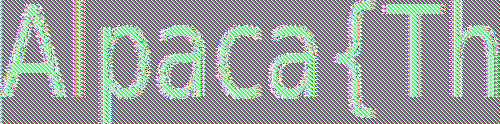

In [ ]:
Image.frombytes("RGBA", (7124 // 4, 124), data[header_len:]).transpose(Image.FLIP_TOP_BOTTOM).crop((0, 0, 500, 124))